## mnist dataset which is set of  70000 small images of digits handwritten by high school students and employes of the US census Bureau.ech image is labelled with the digit it represent 

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784',version=1,as_frame=False)

In [2]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
X,y=mnist['data'],mnist['target']

In [4]:
X.shape


(70000, 784)

In [5]:
y.shape

(70000,)

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl

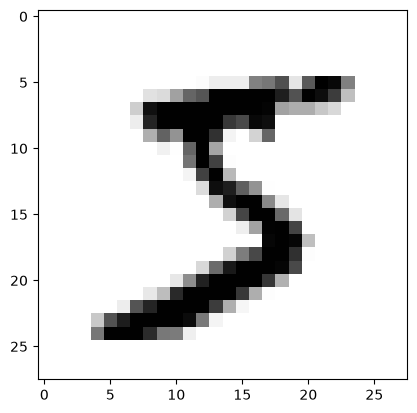

In [7]:
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap='binary')
plt.show()

In [8]:
y[0]

'5'

In [9]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 784), (10000, 784), (60000,), (10000,))

In [11]:
y_train.dtype

dtype('O')

In [12]:
y_train[:10]

array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4'], dtype=object)

In [42]:
# converting the training dataset string to integer
y_train_int=y_train.astype(int)
y_test_int=y_test.astype(int)



In [48]:
X_train_dummy = X_train / 255.0
X_test_dummy = X_test / 255.0

In [49]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=100, solver='lbfgs')

In [50]:
log_reg.fit(X_train_dummy, y_train_int)

C:\Users\Student\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [54]:
y_pred = log_reg.predict(X_test_dummy)

In [55]:
Sample = X_test_dummy[0].reshape(1, -1)

print("Actual:", y_test_int[0])
print("Predicted:", log_reg.predict(Sample)[0])

Actual: 7
Predicted: 7


## Check the probabilities for the first test image"

In [21]:
print(y_prob[0])

[1.15854313e-09 5.50284681e-20 2.60601068e-10 3.00620776e-03
 4.21475014e-09 3.07394760e-06 8.28079611e-16 9.96841574e-01
 1.59682780e-05 1.33170158e-04]


In [22]:
print("Predicted digit:", log_reg.classes_[y_prob[0].argmax()])
print("Probability:", y_prob[0].max())

Predicted digit: 7
Probability: 0.9968415742268701


In [23]:
print(y_prob)

[[1.15854313e-09 5.50284681e-20 2.60601068e-10 ... 9.96841574e-01
  1.59682780e-05 1.33170158e-04]
 [1.76231764e-07 2.46504730e-10 9.87949548e-01 ... 1.72528837e-37
  3.74864783e-07 2.39742732e-26]
 [1.13085513e-08 9.95542542e-01 2.58743064e-03 ... 7.78422194e-07
  1.27765386e-03 8.40372875e-05]
 ...
 [6.02782346e-12 7.89875841e-13 1.37853179e-07 ... 4.11464216e-04
  3.05723432e-03 1.22195235e-02]
 [2.72028123e-14 5.00419411e-13 1.10445186e-11 ... 1.34992294e-10
  8.64152759e-04 4.37420270e-11]
 [5.99676624e-11 2.51526115e-24 7.26802846e-06 ... 2.16516473e-21
  1.78549328e-11 4.34878352e-16]]


In [24]:
y_prob = log_reg.predict_proba(X_test)

print("Probabilities of first image:")
print(y_prob[0])

print("Predicted digit:", log_reg.classes_[y_prob[0].argmax()])
print("Highest probability:", y_prob[0].max())

Probabilities of first image:
[1.15854313e-09 5.50284681e-20 2.60601068e-10 3.00620776e-03
 4.21475014e-09 3.07394760e-06 8.28079611e-16 9.96841574e-01
 1.59682780e-05 1.33170158e-04]
Predicted digit: 7
Highest probability: 0.9968415742268701


In [26]:
from sklearn.linear_model import LogisticRegression

In [ ]:
cm=confusionmatrix

In [27]:
log_reg = LogisticRegression()

In [31]:
y_pred = log_reg.predict(X_test)

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 954    0    4    2    1    5    6    4    4    0]
 [   0 1109    8    3    0    1    3    2    9    0]
 [   5   13  914   19   12    6   11   10   39    3]
 [   3    1   19  921    2   23    3   11   21    6]
 [   3    3    6    5  912    0   10    6   10   27]
 [  12    5    3   36   12  762   16    6   34    6]
 [   9    3    9    2    7   18  907    1    2    0]
 [   4    8   25    7    4    2    0  945    3   30]
 [   7   14    5   22    6   23   10   13  862   12]
 [   8    6    1    9   20    7    1   23   11  923]]


In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 954    0    4    2    1    5    6    4    4    0]
 [   0 1109    8    3    0    1    3    2    9    0]
 [   5   13  914   19   12    6   11   10   39    3]
 [   3    1   19  921    2   23    3   11   21    6]
 [   3    3    6    5  912    0   10    6   10   27]
 [  12    5    3   36   12  762   16    6   34    6]
 [   9    3    9    2    7   18  907    1    2    0]
 [   4    8   25    7    4    2    0  945    3   30]
 [   7   14    5   22    6   23   10   13  862   12]
 [   8    6    1    9   20    7    1   23   11  923]]


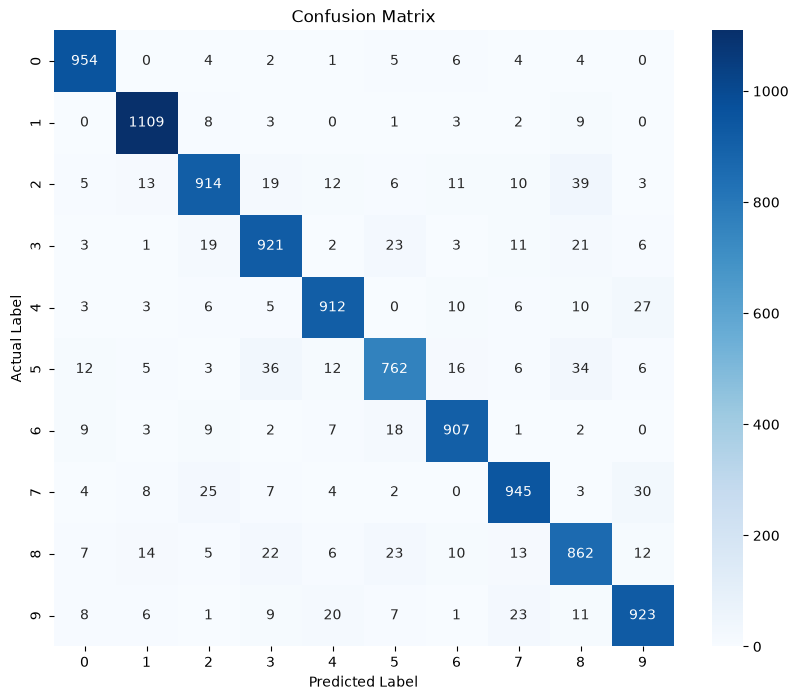

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [61]:
# Make predictions
y_pred = log_reg.predict(X_test_dummy)

In [62]:
# Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test_int, y_pred))




              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.91      0.88      0.89       892
           6       0.94      0.95      0.94       958
           7       0.94      0.92      0.93      1028
           8       0.87      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



In [67]:
import sys
print(sys.executable)

C:\Users\Student\anaconda3\python.exe


In [68]:
import sys
!{sys.executable} -m pip install opencv-python

  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)


In [69]:
import cv2
print(cv2.__version__)

5.0.0


In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [73]:
import sys
print(sys.executable)

C:\Users\Student\anaconda3\python.exe


In [74]:
!{sys.executable} -m pip show opencv-python

Name: opencv-python
Version: 5.0.0.93
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: C:\Users\Student\anaconda3\Lib\site-packages
Requires: numpy
Required-by: 


In [79]:
import os

print(os.getcwd())

C:\Users\Student\alvas_engineering


In [80]:
import os

print(os.path.exists('4_i.png'))

False


In [81]:
image = cv2.imread(r"C:\Users\Student\Downloads\4_i.png")

(452, 451, 3)


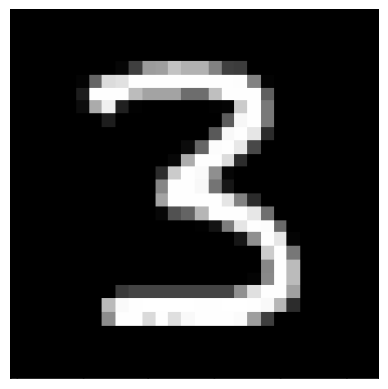

In [87]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('4.png')

print(image.shape)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [92]:
# Convert into grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blurring the gray image
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Threshold
_, threshold = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

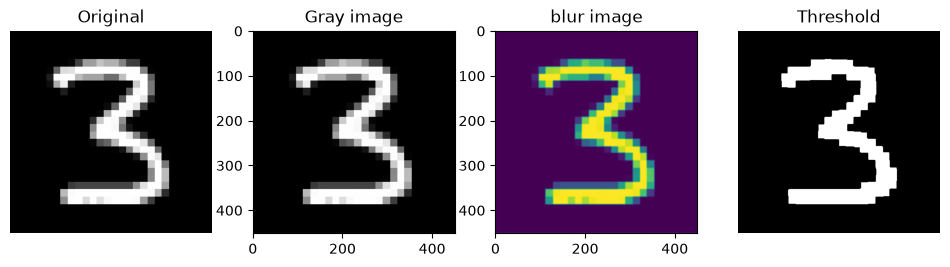

In [100]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gray, cmap="gray")
plt.title("Gray image")

plt.subplot(1,4,3)
plt.imshow(blur)
plt.title("blur image")

plt.subplot(1,4,4)
plt.imshow(threshold, cmap="gray")
plt.title("Threshold")
plt.axis("off")

plt.show()

In [104]:
contours, _ = cv2.findContours(
    threshold,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

Number of contours: 1


In [108]:
# find the largest contour
largest_contour = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(largest_contour)

In [109]:
print("Bounding box")
print("x", x)
print("y", y)
print("width", w)
print("height", h)

Bounding box
x 97
y 63
width 258
height 324


<Figure size 640x480 with 0 Axes>

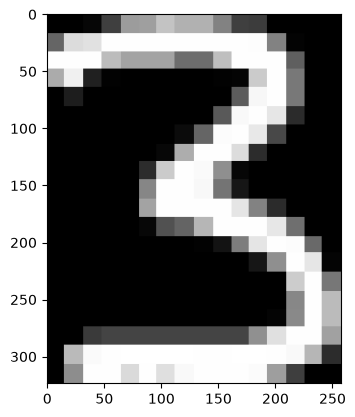

<Figure size 640x480 with 0 Axes>

In [112]:
# Crop the image
crop_digit = image[y:y+h, x:x+w]

# Display the cropped digit
plt.imshow(cv2.cvtColor(crop_digit, cv2.COLOR_BGR2RGB))
plt.figure()

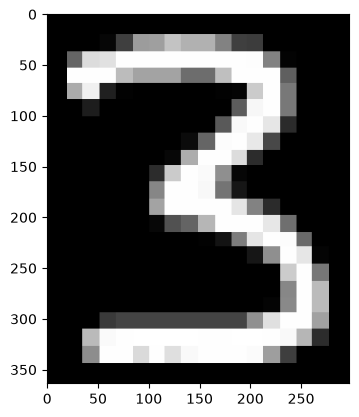

In [117]:
# Add padding to the image
padding = 20

digit_padded = cv2.copyMakeBorder(
    crop_digit,
    padding,
    padding,
    padding,
    padding,
    cv2.BORDER_CONSTANT,
    value=0
)

plt.imshow(digit_padded, cmap="gray")
plt.show()